Proceed by declaring and calling functions in the cnn_model.py file.

In [ ]:
#pip install tensorflow is required.

In [ ]:
#Check the version for sure of installation
import tensorflow as tf
tf.__version__

'2.20.0'

In [ ]:
pip install keras
pip install opencv-python

pip install matplotlib
pip install sklearn
pip install scikit-learn

pip install --upgrade tensorflow

In [ ]:
## lib and module import

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import cnn_model  # cnn import in the same path


In [ ]:
# Specify Inputs and Outputs

im_rows = 32  # Image height
im_cols = 32  # Image width
im_color = 3  # Image color space (e.g., 3 for RGB)
in_shape = (im_rows, im_cols, im_color) # Input image shape
nb_classes = 12 # Number of classes

현재 데이터의 형태: (3199, 32, 32, 3)
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.2493 - loss: 3.4155 - val_accuracy: 0.1031 - val_loss: 3.9906 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.3755 - loss: 2.9678 - val_accuracy: 0.1437 - val_loss: 4.1195 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.4338 - loss: 2.7478 - val_accuracy: 0.1625 - val_loss: 3.9941 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.4529 - loss: 2.6022 - val_accuracy: 0.1953 - val_loss: 3.8603 - learning_rate: 0.0010
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.4865 - loss: 2.4901 - val_accuracy: 0.1969 - val_loss: 3.5237 - learning_rate: 0.0010
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.5178 - loss: 2.4010 - val_accuracy: 0.3609 - val_loss: 2.9119 - learning_rate: 0.0010
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 

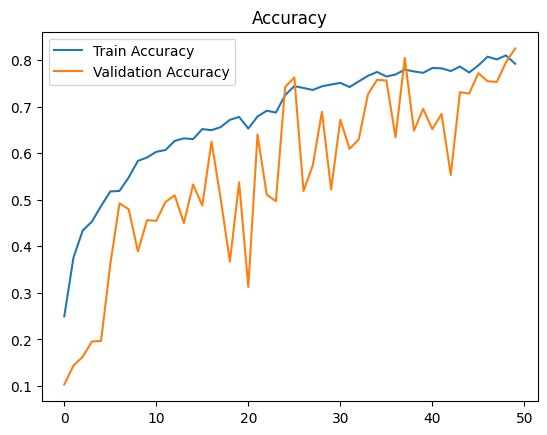

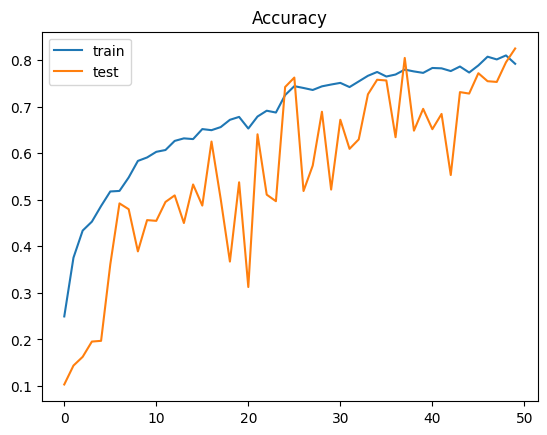

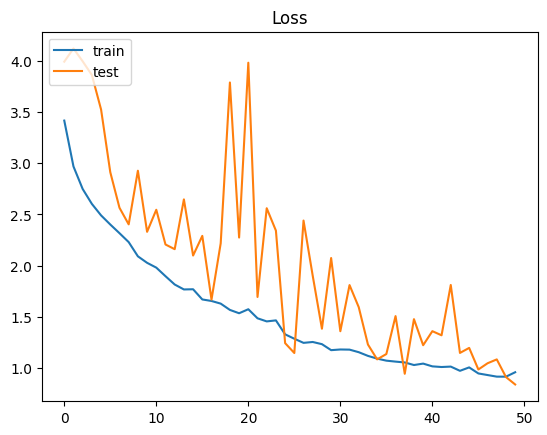

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8250 - loss: 0.8394
정답률= 0.824999988079071 loss= 0.8394415974617004


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import cnn_model  

# Data Loading and Preprocessing
photos = np.load("C:\\Users\\wade\\Desktop\\healthML\\dataSet\\foodDataSet.npz")
x = photos['x']
y = photos['y']

print("current data form:", x.shape)

# Image Data Preprocessing: Normalization to values between 0 and 1
x = x.astype('float32') / 255

# Automatic Class Count Detection
nb_classes = len(np.unique(y))

# Convert Label Data to One-Hot Encoding Format
y = to_categorical(y, nb_classes)

# Separate dataset as training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.8, random_state=42)

# Model Creation and Compilation (Maintain default optimizer settings, LR=0.001)
in_shape = x_train.shape[1:] 
nb_classes = y_train.shape[1]
model = cnn_model.create_model(in_shape, nb_classes)

# model complie
model.compile(
    # Revert LR from 0.0003 back to 0.001 to recover potential speed and performance
    optimizer=Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# data generation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.25,  
    height_shift_range=0.25, 
    shear_range=0.2,
    zoom_range=0.25,         
    horizontal_flip=True,
    fill_mode='nearest'
)

# set the call back for escaping Overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7, 
    verbose=1
)

callbacks_list = [early_stop, lr_schedule]


# set the epochs for training
epochs = 50
batch_size = 32

# Calculation using with steps_per_epoch and np.ceil (avoiding UserWarning)
steps_per_epoch = int(np.ceil(len(x_train) / batch_size))

# Training with Data Augmentation Applied
hist = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
                 steps_per_epoch=steps_per_epoch,
                 epochs=epochs,
                 validation_data=(x_test, y_test),
                 callbacks=callbacks_list)

# Visualization of Results
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Plotting the Training Status and Accuracy trend
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# loss graph
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# model evaluation as accuracy
score = model.evaluate(x_test, y_test, verbose=1)
print('accuracy=', score[1], 'loss=', score[0])

In [ ]:
# save the trained model (Keras)
model.save('trained_model.keras')